In [12]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os
import tensorflow as tf


In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [4]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [5]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

In [8]:
def smape_loss(y_true, y_pred):
    epsilon = 1e-6
    numerator = tf.abs(y_true - y_pred)
    denominator = (tf.abs(y_true) + tf.abs(y_pred)) / 2.0
    return tf.reduce_mean(numerator / tf.maximum(denominator, epsilon))


def mae_smape_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    smape = smape_loss(y_true, y_pred)

    alpha = 0.5  # MAE weight
    beta = 0.5   # SMAPE weight

    return alpha * mae + beta * smape


Processing: RevenueCenter_2
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 423ms/step - loss: 0.5044 - mae: 0.1034 - val_loss: 0.3675 - val_mae: 0.1303
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 423ms/step - loss: 0.4172 - mae: 0.0867 - val_loss: 0.4175 - val_mae: 0.1446
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 429ms/step - loss: 0.3934 - mae: 0.0836 - val_loss: 0.3710 - val_mae: 0.1314
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 443ms/step - loss: 0.3939 - mae: 0.0853 - val_loss: 0.3603 - val_mae: 0.1282
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 381ms/step - loss: 0.3817 - mae: 0.0843 - val_loss: 0.3809 - val_mae: 0.1343
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 367ms/step - loss: 0.3816 - mae: 0.0838 - val_loss: 0.3859 - val_mae: 0.1358
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step - loss: 0.4080 - mae: 0.0876 - val_loss: 0.3614 - val_mae: 0.1285
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step - loss: 0.4082 - mae: 0.0923 - val_loss: 0.4135 - val_mae: 0.1436
Epoch 9/100
2

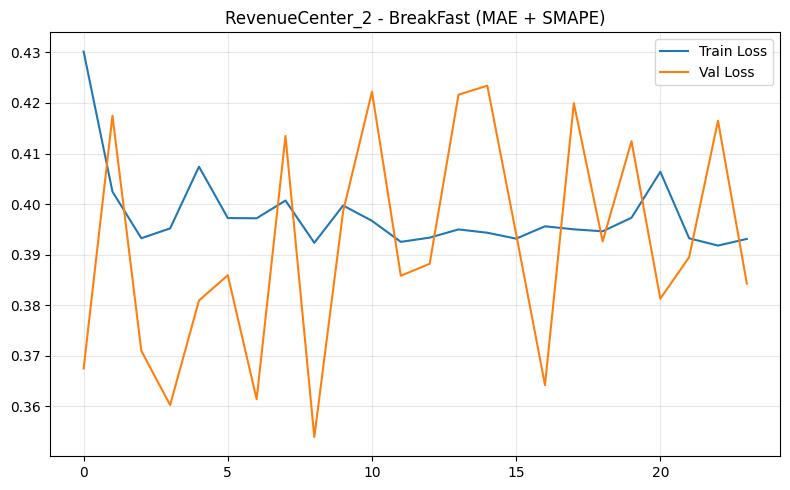

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


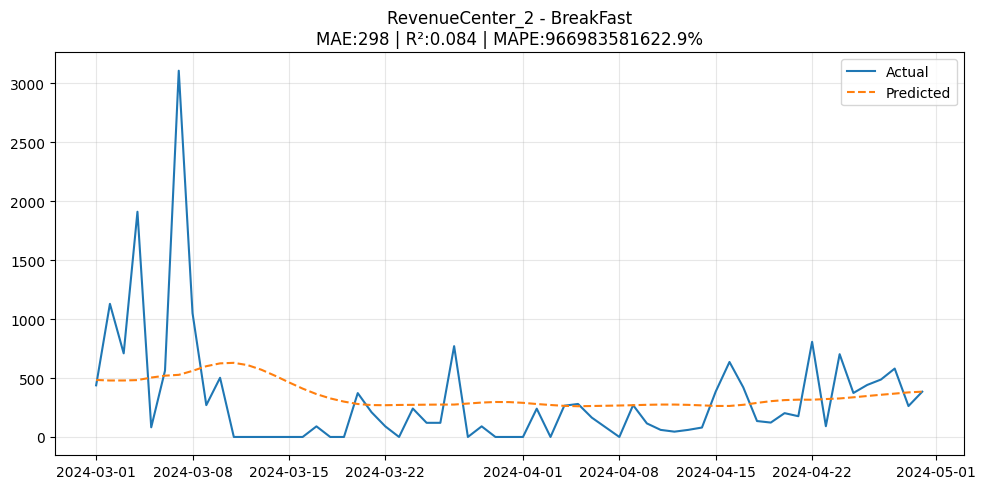

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 407ms/step - loss: 0.4865 - mae: 0.1072 - val_loss: 0.3619 - val_mae: 0.1715
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 356ms/step - loss: 0.3485 - mae: 0.0849 - val_loss: 0.4066 - val_mae: 0.1866
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 390ms/step - loss: 0.3722 - mae: 0.0872 - val_loss: 0.3456 - val_mae: 0.1652
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 378ms/step - loss: 0.3647 - mae: 0.0958 - val_loss: 0.3644 - val_mae: 0.1726
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 406ms/step - loss: 0.3827 - mae: 0.0946 - val_loss: 0.3670 - val_mae: 0.1735
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 346ms/step - loss: 0.3536 - mae: 0.0864 - val_loss: 0.3648 - val_mae: 0.1726
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 355ms/step - loss: 0.3539 - mae: 0.0869 - val_loss: 0.3643 - val_mae: 0.1726
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 394ms/step - loss: 0.3549 - mae: 0.0859 - val_loss: 0.3511 - val_mae: 0.1676
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 418

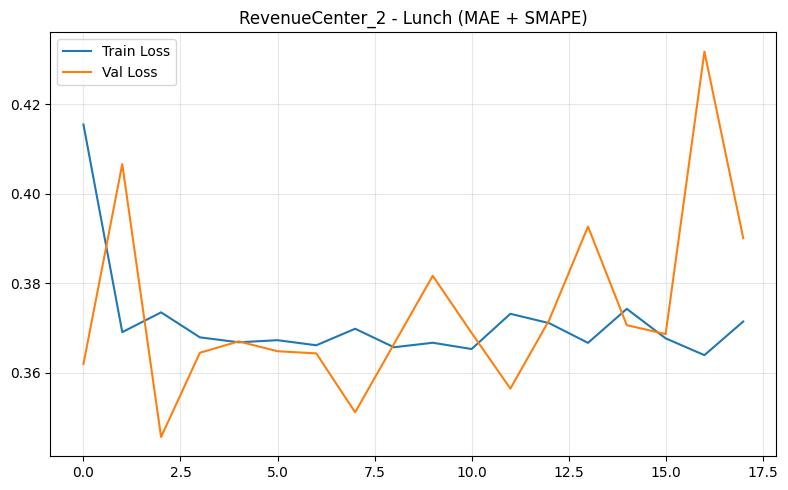

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


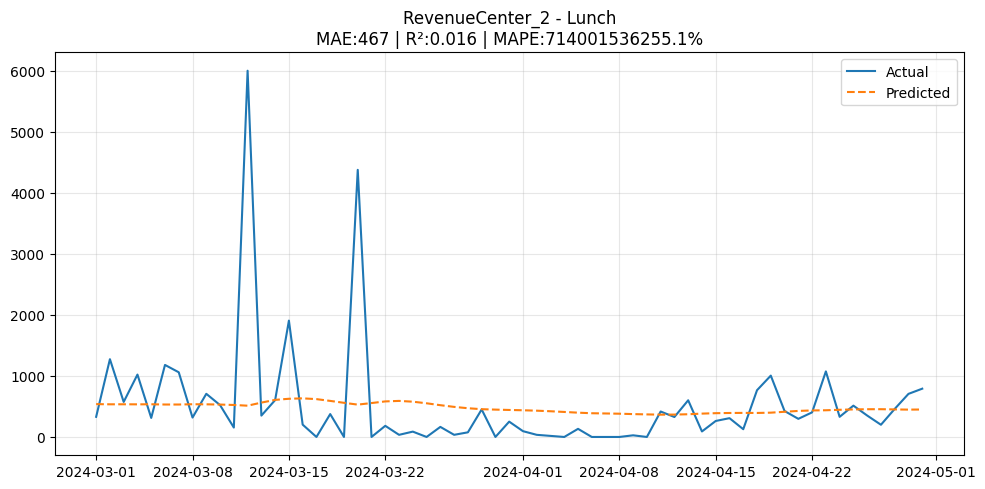

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 436ms/step - loss: 0.4591 - mae: 0.0339 - val_loss: 0.4719 - val_mae: 0.0901
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 390ms/step - loss: 0.3592 - mae: 0.0270 - val_loss: 0.5137 - val_mae: 0.0943
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 387ms/step - loss: 0.3478 - mae: 0.0303 - val_loss: 0.4609 - val_mae: 0.0889
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 365ms/step - loss: 0.3364 - mae: 0.0259 - val_loss: 0.4919 - val_mae: 0.0921
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 394ms/step - loss: 0.3356 - mae: 0.0298 - val_loss: 0.5089 - val_mae: 0.0938
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 417ms/step - loss: 0.3333 - mae: 0.0278 - val_loss: 0.4738 - val_mae: 0.0903
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 390ms/step - loss: 0.3324 - mae: 0.0267 - val_loss: 0.3912 - val_mae: 0.0811
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - loss: 0.3456 - mae: 0.0302 - val_loss: 0.4922 - val_mae: 0.0921
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 39

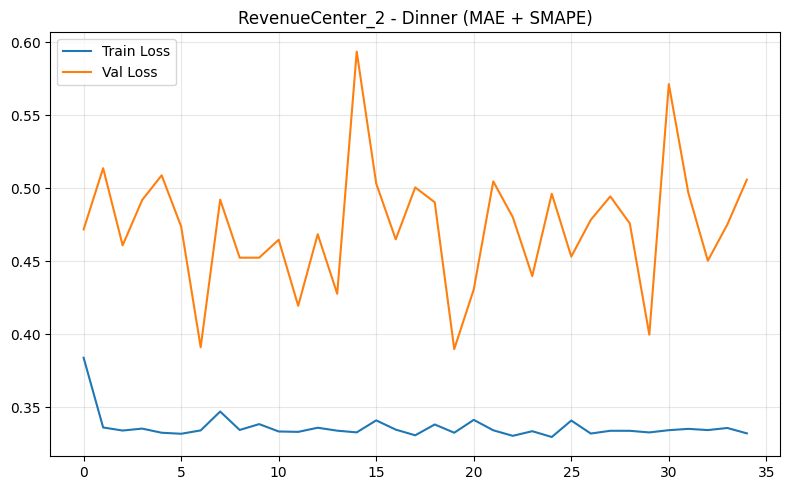

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


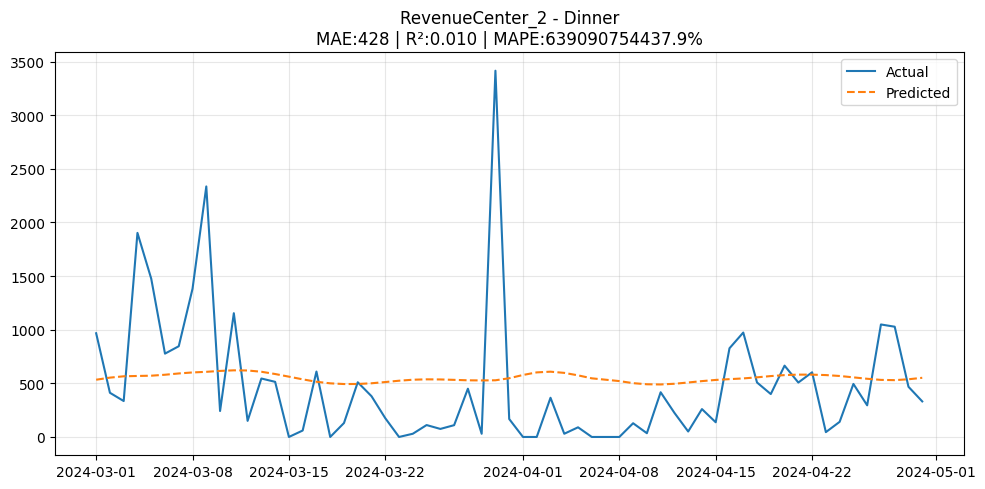

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_8
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 418ms/step - loss: 0.9676 - mae: 0.0795 - val_loss: 1.0060 - val_mae: 0.0144
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 404ms/step - loss: 0.9909 - mae: 0.0502 - val_loss: 1.0118 - val_mae: 0.0341
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 382ms/step - loss: 0.9754 - mae: 0.0502 - val_loss: 1.0118 - val_mae: 0.0339
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 421ms/step - loss: 0.9904 - mae: 0.0421 - val_loss: 1.0152 - val_mae: 0.0455
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 437ms/step - loss: 0.9951 - mae: 0.0568 - val_loss: 1.0190 - val_mae: 0.0569
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 428ms/step - loss: 0.9977 - mae: 0.0672 - val_loss: 1.0187 - val_mae: 0.0559
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 399ms/step - loss: 0.9815 - mae: 0.0549 - val_loss: 1.0107 - val_mae: 0.0311
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 437ms/step - loss: 0.9880 - mae: 0.0584 - val_loss: 1.0142 - v

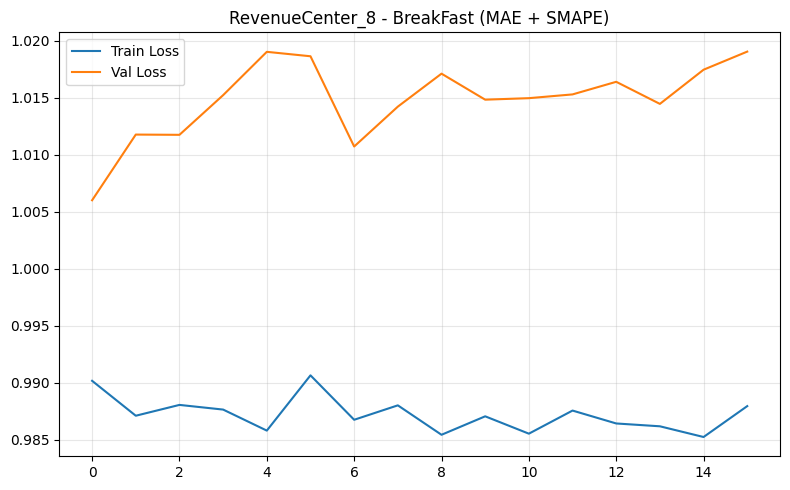

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


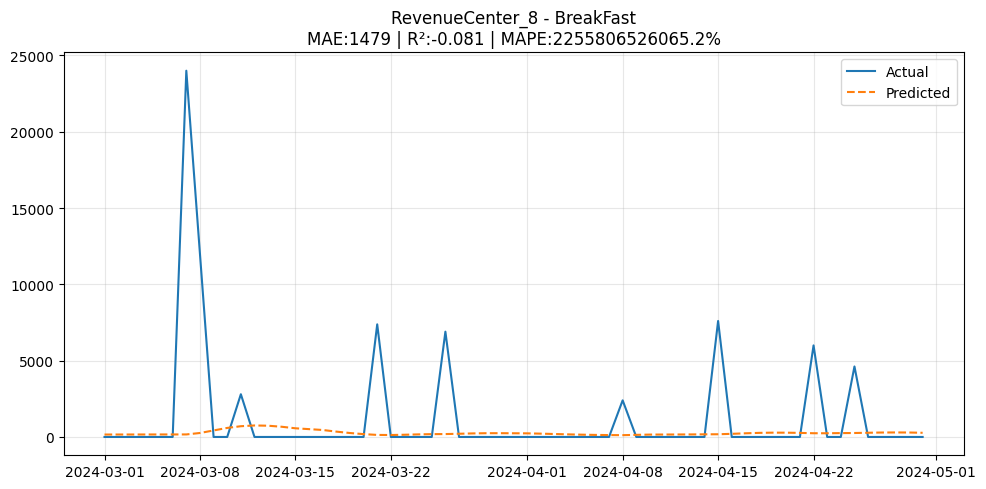

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 528ms/step - loss: 0.7909 - mae: 0.1118 - val_loss: 0.7853 - val_mae: 0.2159
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 484ms/step - loss: 0.7833 - mae: 0.0911 - val_loss: 0.7624 - val_mae: 0.2166
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 446ms/step - loss: 0.7262 - mae: 0.1021 - val_loss: 0.7427 - val_mae: 0.2254
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 423ms/step - loss: 0.7401 - mae: 0.1021 - val_loss: 0.7635 - val_mae: 0.2155
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 475ms/step - loss: 0.7504 - mae: 0.1142 - val_loss: 0.7597 - val_mae: 0.2164
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 447ms/step - loss: 0.7376 - mae: 0.1005 - val_loss: 0.7601 - val_mae: 0.2234
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 458ms/step - loss: 0.7421 - mae: 0.1045 - val_loss: 0.7889 - val_mae: 0.2134
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 423ms/step - loss: 0.7158 - mae: 0.0963 - val_loss: 0.7996 - val_mae: 0.2236
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 44

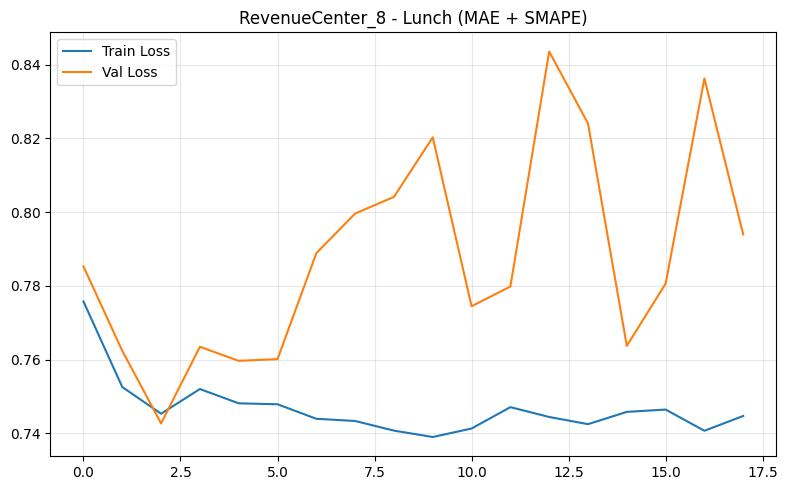

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


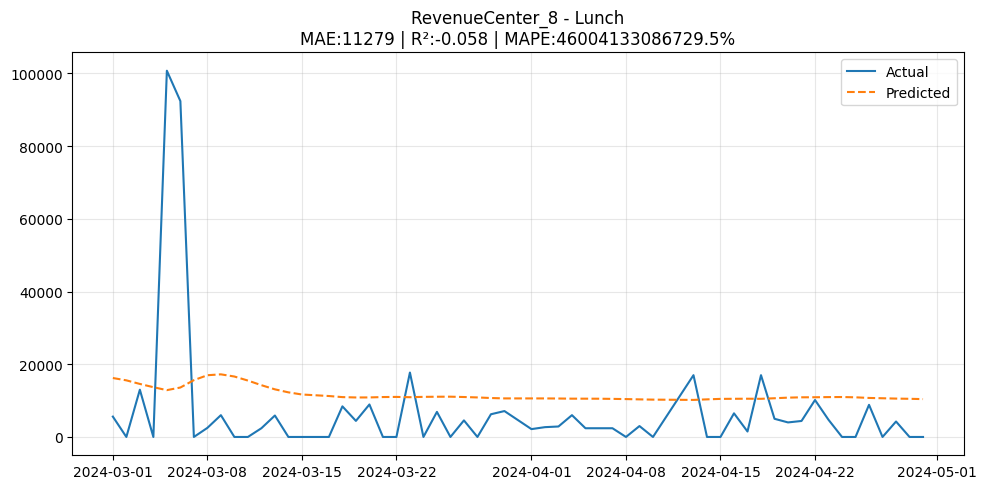

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 536ms/step - loss: 0.6964 - mae: 0.1026 - val_loss: 0.7299 - val_mae: 0.1833
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 421ms/step - loss: 0.5956 - mae: 0.0901 - val_loss: 0.6953 - val_mae: 0.1792
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 372ms/step - loss: 0.5380 - mae: 0.0832 - val_loss: 0.6010 - val_mae: 0.1672
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 408ms/step - loss: 0.5600 - mae: 0.0923 - val_loss: 0.6613 - val_mae: 0.1747
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 400ms/step - loss: 0.5331 - mae: 0.0876 - val_loss: 0.6505 - val_mae: 0.1733
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 359ms/step - loss: 0.5856 - mae: 0.1020 - val_loss: 0.6753 - val_mae: 0.1766
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 406ms/step - loss: 0.5676 - mae: 0.0940 - val_loss: 0.6198 - val_mae: 0.1690
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 417ms/step - loss: 0.6207 - mae: 0.1076 - val_loss: 0.6557 - val_mae: 0.1740
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 394m

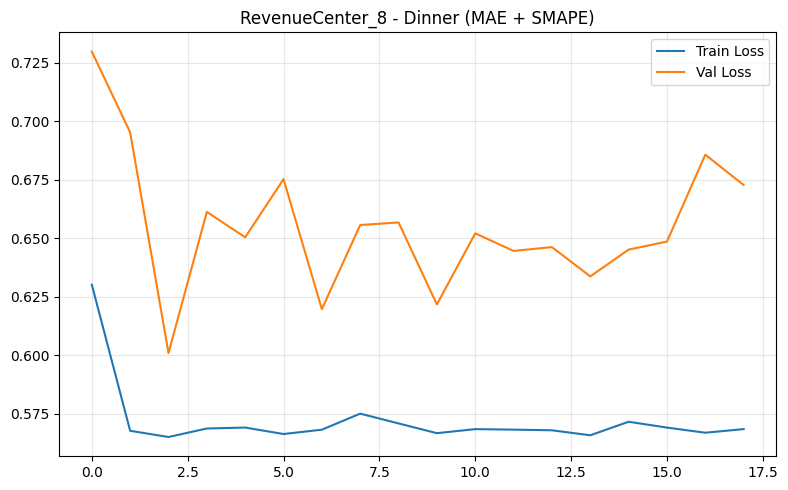

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


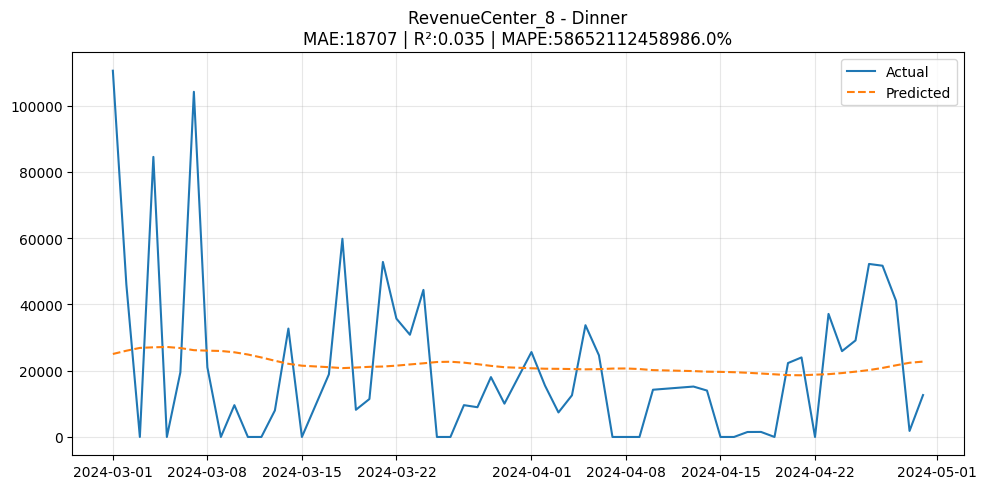

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_7
Epoch 1/100
13/21 ━━━━━━━━━━━━━━━━━━━━ 4s 551ms/step - loss: 0.7500 - mae: 0.0821

KeyboardInterrupt: 

In [15]:

WINDOW = 30
EPOCHS = 100
BATCH_SIZE = 16

for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print(f"\nProcessing: {center_name}")

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    # -------------------------
    # Load & prepare data
    # -------------------------
    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            print(f"Skipping {center_name} - {meal} (constant values)")
            continue

        # -------------------------
        # Scaling
        # -------------------------
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled = scaler.transform(test_df[["y"]])

        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test = X_test.reshape(-1, WINDOW, 1)

        # =================================================
        # MODEL — TANH LSTM (DEPTH > WIDTH)
        # =================================================
        model = Sequential([
            Input(shape=(WINDOW, 1)),

            LSTM(512, activation="tanh", return_sequences=True),
            LSTM(256, activation="tanh", return_sequences=True),
            LSTM(128, activation="tanh"),

            Dense(1)
        ])

        model.compile(
            optimizer="adam",
            loss=mae_smape_loss,
            metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        # -------------------------
        # Training
        # -------------------------
        history = model.fit(
            X_train,
            y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =================================================
        # LOSS PLOT
        # =================================================
        plt.figure(figsize=(8, 5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (MAE + SMAPE)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_mae_smape.png"), dpi=300)
        plt.show()
        plt.close()

        # =================================================
        # PREDICTIONS & METRICS (UNSCALED)
        # =================================================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred = scaler.inverse_transform(model.predict(X_test))

        y_train_true = scaler.inverse_transform(y_train.reshape(-1, 1))
        y_test_true = scaler.inverse_transform(y_test.reshape(-1, 1))

        train_mae = mean_absolute_error(y_train_true, y_train_pred)
        train_r2 = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae = mean_absolute_error(y_test_true, y_test_pred)
        test_r2 = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        # =================================================
        # TEST PLOT
        # =================================================
        plt.figure(figsize=(10, 5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal}\n"
            f"MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_mae_smape.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — MAE + SMAPE MODEL")

In [ ]:
y_min = y_train.min()
y_max = y_train.max()

print("Target range:", y_min, "to", y_max)
print("Range width:", y_max - y_min)

Target range: 0.0 to 37870.0
Range width: 37870.0
